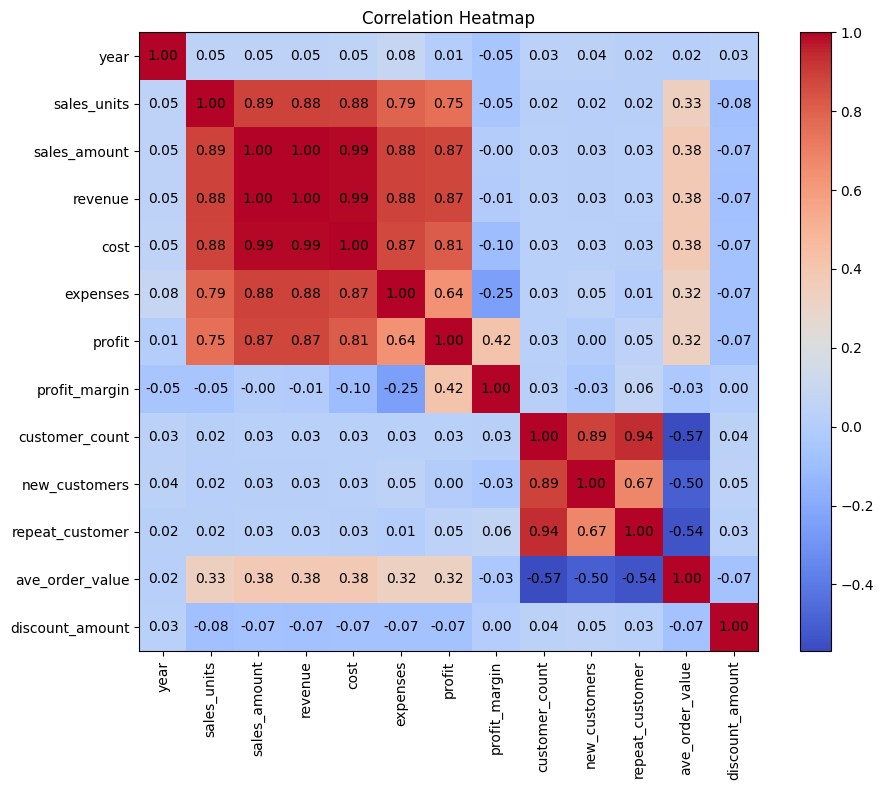

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Add correlation values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


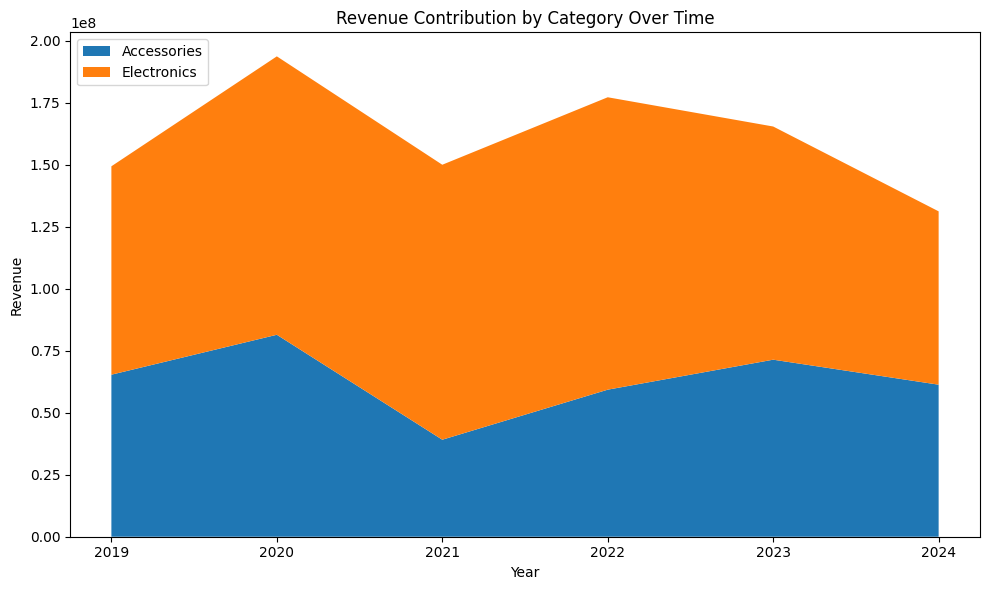

In [4]:
category_year = df.groupby(['year','category'])['revenue'].sum().unstack()

plt.figure(figsize=(10,6))
plt.stackplot(category_year.index,
              category_year.T,
              labels=category_year.columns)

plt.legend(loc='upper left')
plt.title("Revenue Contribution by Category Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


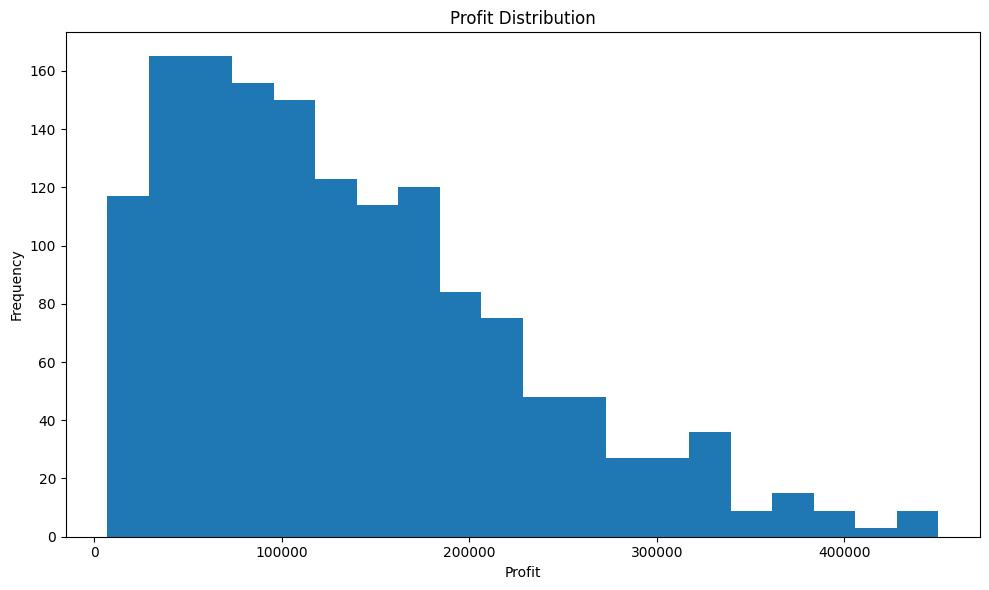

In [5]:
plt.figure(figsize=(10,6))
plt.hist(df['profit'], bins=20)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3716797774.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(region_groups, labels=df['region'].unique())


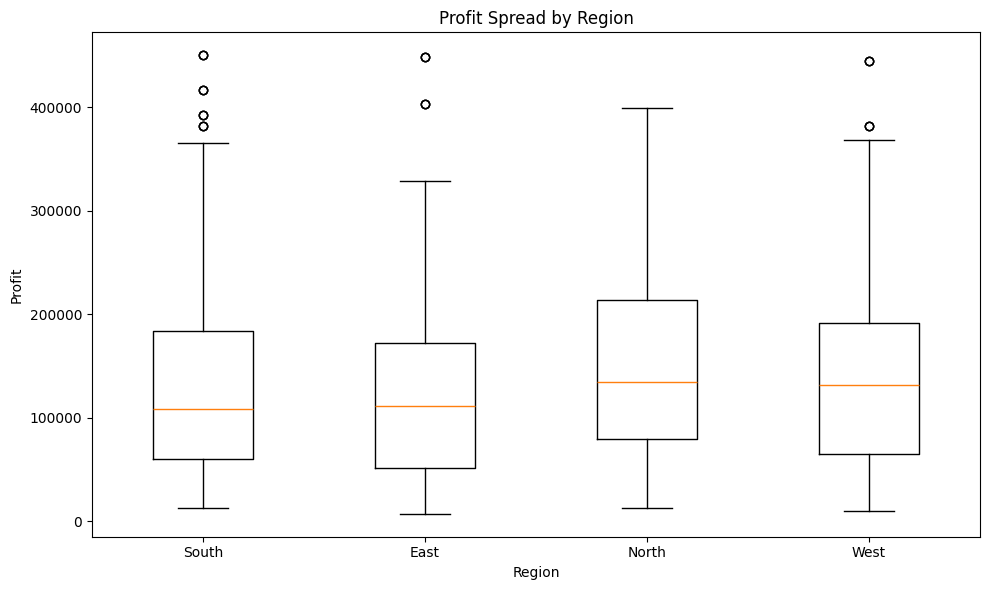

In [6]:
region_groups = [df[df['region']==r]['profit'] for r in df['region'].unique()]

plt.figure(figsize=(10,6))
plt.boxplot(region_groups, labels=df['region'].unique())

plt.title("Profit Spread by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


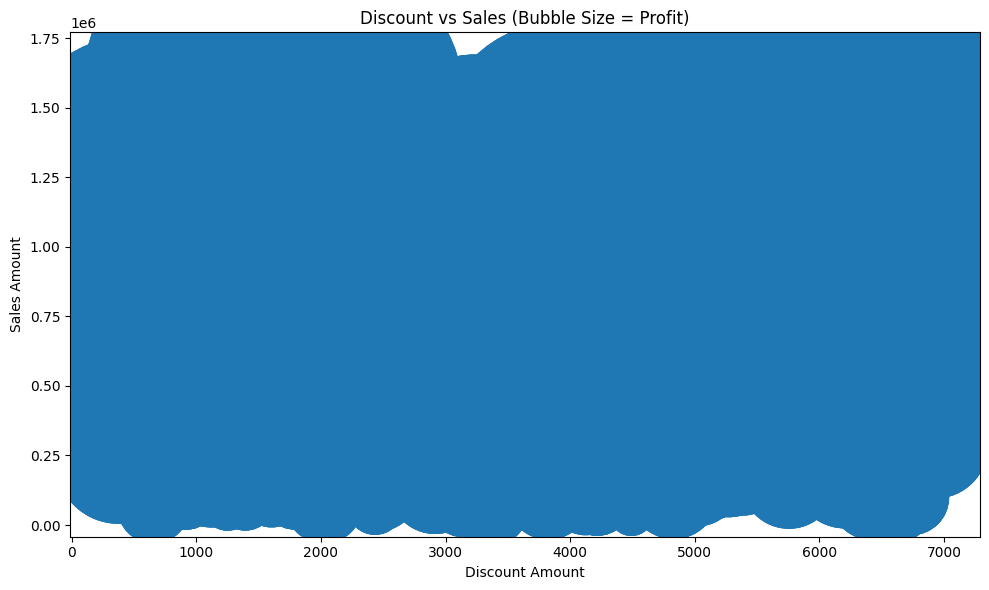

In [7]:
plt.figure(figsize=(10,6))

sizes = df['profit'] * 0.1  # scale size

plt.scatter(df['discount_amount'],
            df['sales_amount'],
            s=sizes)

plt.title("Discount vs Sales (Bubble Size = Profit)")
plt.xlabel("Discount Amount")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()


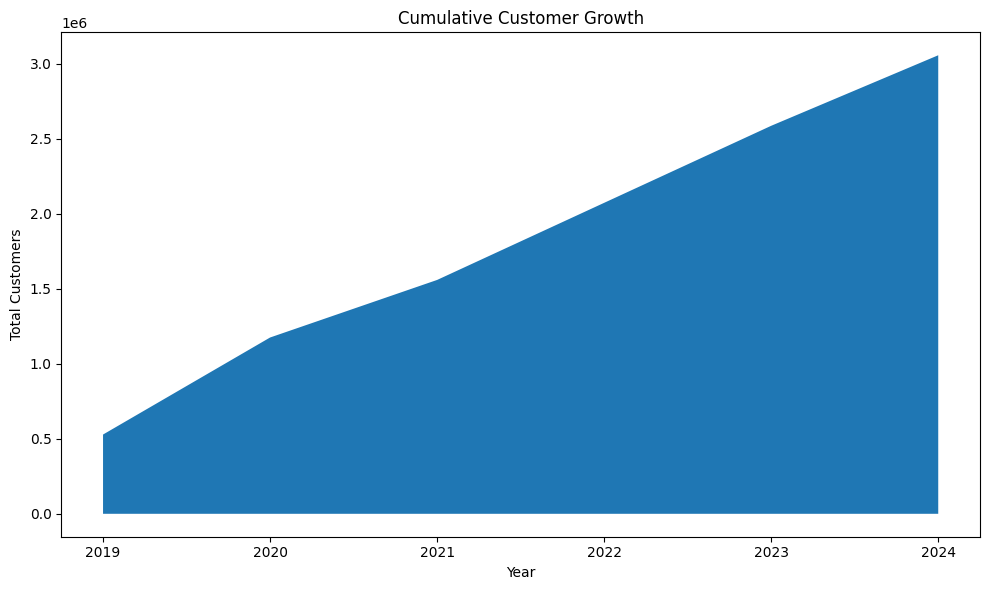

In [8]:
customer_year = df.groupby('year')['customer_count'].sum().cumsum()

plt.figure(figsize=(10,6))
plt.fill_between(customer_year.index,
                 customer_year.values)

plt.title("Cumulative Customer Growth")
plt.xlabel("Year")
plt.ylabel("Total Customers")
plt.tight_layout()
plt.show()


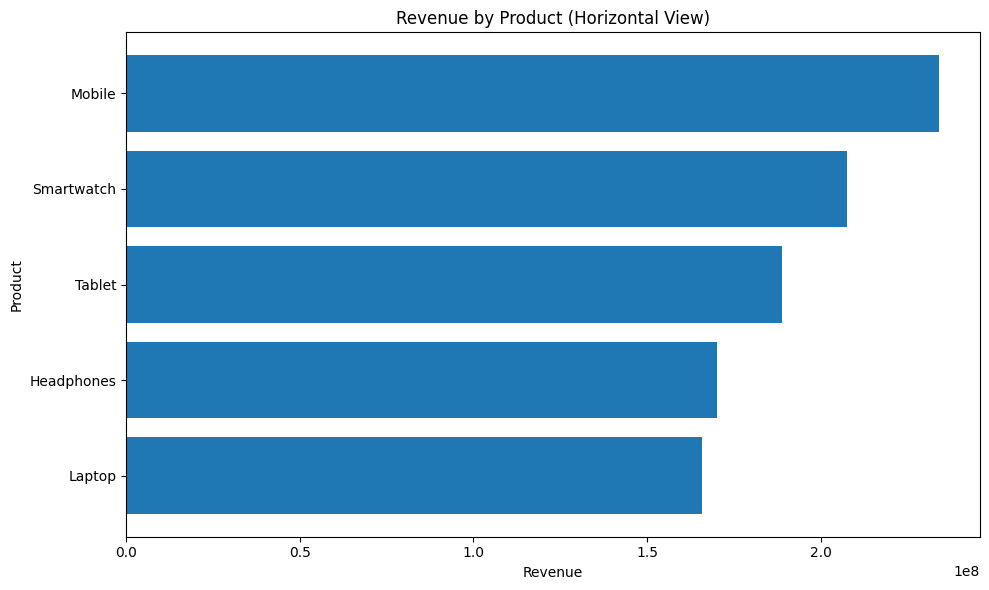

In [9]:
top_products = df.groupby('product_name')['revenue'].sum().sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_products.index, top_products.values)

plt.title("Revenue by Product (Horizontal View)")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


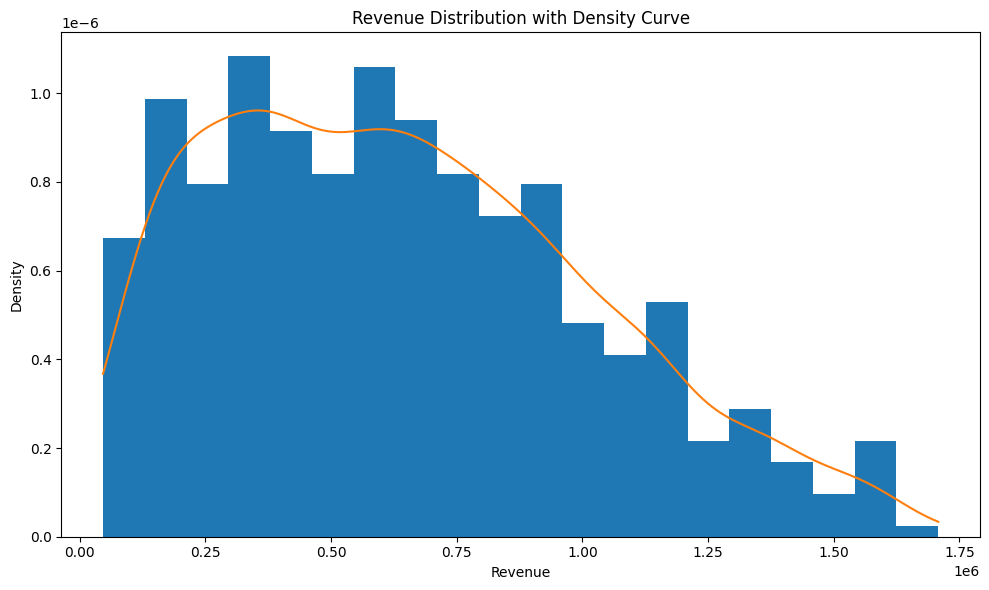

In [10]:
from scipy.stats import gaussian_kde

data = df['revenue']
density = gaussian_kde(data)
xs = np.linspace(min(data), max(data), 200)

plt.figure(figsize=(10,6))
plt.hist(data, bins=20, density=True)
plt.plot(xs, density(xs))

plt.title("Revenue Distribution with Density Curve")
plt.xlabel("Revenue")
plt.ylabel("Density")
plt.tight_layout()
plt.show()
